## Error Analysis
---
Making sure that before improving the accuracy of the SVM model if it still performs better under deeper testing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/processed/WELFake_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (62704, 14)


In [6]:
# TF-IDF again 

X = df["processed_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# training the model

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9668


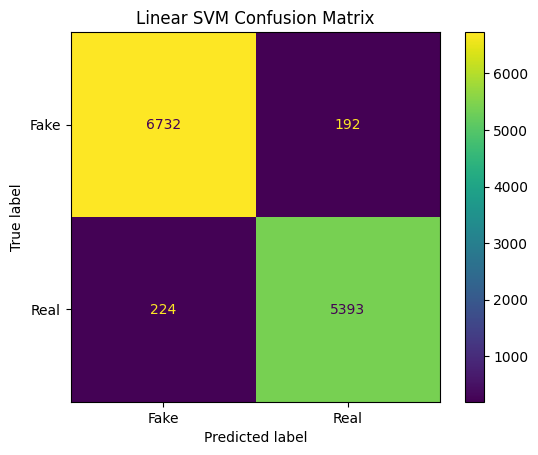

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title("Linear SVM Confusion Matrix")
plt.show()

In [9]:
error_df = df.loc[X_test.index].copy()

error_df["actual_label"] = y_test
error_df["predicted_label"] = y_pred

error_df["decision_score"] = svm_model.decision_function(X_test_tfidf)

error_df["correct"] = (
    error_df["actual_label"] == error_df["predicted_label"]
)

print("Total test articles:", len(error_df))
print("Incorrect predictions:", (~error_df["correct"]).sum())

Total test articles: 12541
Incorrect predictions: 416


In [10]:
false_positives = error_df[
    (error_df["actual_label"] == 1) &
    (error_df["predicted_label"] == 0)
]

false_negatives = error_df[
    (error_df["actual_label"] == 0) &
    (error_df["predicted_label"] == 1)
]

print("Real → Fake:", len(false_positives))
print("Fake → Real:", len(false_negatives))

Real → Fake: 224
Fake → Real: 192


### Creating an error-analysis dataframe
---

In [ ]:
# Mistakes the model made with high uncertainty

errors = error_df[~error_df["correct"]].copy()

errors["absolute_score"] = errors["decision_score"].abs()

uncertain_errors = errors.sort_values(
    "absolute_score"
)

uncertain_errors[
    ["title", "actual_label", "predicted_label", "decision_score"]
].head(10)

,title,actual_label,predicted_label,decision_score
11483,Links 11/12/16,1,0,-0.000383
4652,Secret Israeli Operation Brings Tons Of Winter...,0,1,0.000858
52447,Vatican Makes Unprecedented Agreement With Chi...,1,0,-0.001378
9635,ILLEGAL ALIEN ARRESTED FOR SHOOTING Teen Girlf...,1,0,-0.001790
292,"Music Video: Russians die, but they never surr...",1,0,-0.002629
55031,The Ugly Truth Of Six More Leftist “Heroes”,1,0,-0.003680
60295,"FLYNN: When You Leave Your Pint at the Bar, th...",0,1,0.004316
23820,ISIS Genocide: Will US Back Up Its Tough Talk?,0,1,0.005062
10397,Thieves Steal Bees that Pollinate Central Vall...,0,1,0.009939
50171,Obama Pushes Castro on Human Rights During Joi...,0,1,0.011500


In [ ]:
# Mistakes the model made with high confidence

confident_errors = errors.sort_values(
    "absolute_score",
    ascending=False
)

confident_errors[
    ["title", "actual_label", "predicted_label", "decision_score"]
].head(10)

,title,actual_label,predicted_label,decision_score
7563,"Thomas Reuters cuts 2000 jobs, spends $200m st...",1,0,-3.645939
5867,Concert plus campaign: Clinton turns to celebr...,1,0,-2.214212
51053,Clinton Camp in Damage-Control Mode Over 'Top ...,0,1,2.051891
7769,"'Basket of deplorables': For once, Hillary tol...",0,1,1.925267
44347,BREAKING: CRUZ WINS BIG IN WISCONSIN…But Can H...,1,0,-1.665118
9429,Billionaires fund anti-Trump delegate push,0,1,1.629315
1507,The Ruthlessly Effective Rebranding of Europe’...,1,0,-1.611625
24181,Donald Trump kicks off final campaign day with...,1,0,-1.562692
26984,WOW! THE WASHINGTON POST Publishes #RealNews S...,1,0,-1.242616
55591,Barney Frank Powerfully Disproves Ben Carson's...,0,1,1.204114


In [20]:
for _, row in uncertain_errors.head(5).iterrows():
    print("=" * 80)
    print("TITLE:", row["title"])
    print("ACTUAL LABEL:", row["actual_label"])
    print("PREDICTED LABEL:", row["predicted_label"])
    print("DECISION SCORE:", round(row["decision_score"], 4))
    print()
    print(row["text"][:1000])
    print()

TITLE: Links 11/12/16
ACTUAL LABEL: 1
PREDICTED LABEL: 0
DECISION SCORE: -0.0004

What Does Trump’s Victory Mean For NATO? NPR. Charles flags the close, which is an unusually pointed admission of the basis of our imperialist project. 
Brexit 
Turkey is swiftly heading towards a regime of terror Bangkok Post (furzy) 
Trump Transition. I am trying, and hope you will help in comments, in pulling the noise out of the signal regarding what Trump will actually do when he becomes President and whether it will succeed, “success” consisting first of it being implemented and second, making him and his Administration appear to be legitimate (as in keeping campaign promises, delivering tangible benefits to voters or powerful interest groups he needs on board). Despite all the changes in messaging over the course of his campaign, Trump was consistent on immigration, trade and lack of infrastructure investment, and depicted all three as ways to improve conditions for workers. And political scientist

In [ ]:
# Checking the length of the articles that the model got wrong

print("Average word count")

print(
    "Correct:",
    error_df.loc[error_df["correct"], "word_count"].mean()
)

print(
    "Incorrect:",
    error_df.loc[~error_df["correct"], "word_count"].mean()
)

error_df.groupby("correct")["word_count"].describe()

Average word count
Correct: 551.714969072165
Incorrect: 758.6706730769231


,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,416.0,758.670673,1067.697764,5.0,316.0,533.0,884.0,15209.0
True,12125.0,551.714969,563.801737,1.0,254.0,415.0,687.0,11670.0


In [ ]:
# Compare false positives and false negatives

print("Average word count:")

print(
    "Real → Fake:",
    false_positives["word_count"].mean()
)

print(
    "Fake → Real:",
    false_negatives["word_count"].mean()
)

Average word count:
Real → Fake: 840.0491071428571
Fake → Real: 663.7291666666666


In [ ]:
# Checking the titles of the articles that the model got wrong

print("REAL → FAKE")

for title in false_positives["title"].head(10):
    print("-", title)

print("\nFAKE → REAL")

for title in false_negatives["title"].head(10):
    print("-", title)

REAL → FAKE
- IN A RULING THAT WILL MAKE OBAMA’S HEAD SPIN, Fed Judge Says Telling Illegals “Show Us Your Papers” Is Not Discriminatory
- How Clinton Campaign Gamed Super PAC Regulations
- BOOM! Fed Judge Ruling UNBLOCKS Trump Travel Ban…Asks ACLU Lawyer: “Where Does It Say Muslim Countries?”
- HOW OBAMA Could Temporarily Fill The Vacancy Left By Justice Scalia With A RADICAL LEFTIST Judge
- Poland is Empowering Women with Free, Nationwide Self Defense Classes
- Trump: No Salary for Me as President
- Marvel Comics Presents 'The Inhumans' in IMAX Theaters
- When the River Ran Red
- Concert plus campaign: Clinton turns to celebrities in homestretch
- Thomas Reuters cuts 2000 jobs, spends $200m streamlining

FAKE → REAL
- Photos: The Arrivals at the 2016 Tony Awards Red Carpet - The New York Times
- OPEC sees oil prices exploding to $200 a barrel
- Clinton Camp in Damage-Control Mode Over 'Top Secret' Emails
- Factbox: How U.S. states responded to Trump panel's voter data request
- Swiss 